<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Customer_Segmentation_with_K_median.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

purchases = [
    57.0, 49.0, 50.0, 43.0, 47.0, 51.0, 44.0, 52.0, 47.0, 49.0, 47.0, 59.0, 50.0,
    45.0, 54.0, 44.0, 51.0, 40.0, 43.0, 51.0, 74.0, 27.0, 29.0, 31.0, 34.0, 8.0,
    29.0, 56.0, 25.0, 33.0, 35.0, 60.0, 34.0, 31.0, 27.0, 8.0, 13.0, 11.0, 8.0,
    12.0, 10.0, 13.0, 8.0, 9.0, 9.0, 6.0, 11.0, 11.0, 10.0, 9.0
]

spending = [
     524.84, 493.09, 532.38, 576.15, 488.29, 488.29, 578.96, 538.37, 476.53, 527.13,
     476.83, 476.71, 512.1, 404.34, 413.75, 471.89, 449.36, 515.71, 454.6, 429.38,
     329.54, 706.85, 295.37, 287.96, 240.86, 271.21, 281.57, 342.28, 313.74, 229.48,
     312.96, 284.6, 272.92, 324.47, 41.24, 107.23, 130.76, 299.28, 131.29, 47.61,
     116.44, 101.74, 194.02, 101.84, 60.25, 95.61, 107.14, 129.56, 89.63, 83.83
]

data=pd.DataFrame({"purchases":purchases,
                   "spending":spending})
print(data)

    purchases  spending
0        57.0    524.84
1        49.0    493.09
2        50.0    532.38
3        43.0    576.15
4        47.0    488.29
5        51.0    488.29
6        44.0    578.96
7        52.0    538.37
8        47.0    476.53
9        49.0    527.13
10       47.0    476.83
11       59.0    476.71
12       50.0    512.10
13       45.0    404.34
14       54.0    413.75
15       44.0    471.89
16       51.0    449.36
17       40.0    515.71
18       43.0    454.60
19       51.0    429.38
20       74.0    329.54
21       27.0    706.85
22       29.0    295.37
23       31.0    287.96
24       34.0    240.86
25        8.0    271.21
26       29.0    281.57
27       56.0    342.28
28       25.0    313.74
29       33.0    229.48
30       35.0    312.96
31       60.0    284.60
32       34.0    272.92
33       31.0    324.47
34       27.0     41.24
35        8.0    107.23
36       13.0    130.76
37       11.0    299.28
38        8.0    131.29
39       12.0     47.61
40       10.0   

In [ ]:
!pip uninstall -y numpy scikit-learn scikit-learn-extra opencv-python opencv-contrib-python opencv-python-headless thinc
!pip install "numpy==1.26.4" "scikit-learn==1.5.2" "scikit-learn-extra==0.3.0"

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Found existing installation: scikit-learn-extra 0.3.0
Uninstalling scikit-learn-extra-0.3.0:
  Successfully uninstalled scikit-learn-extra-0.3.0
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of t

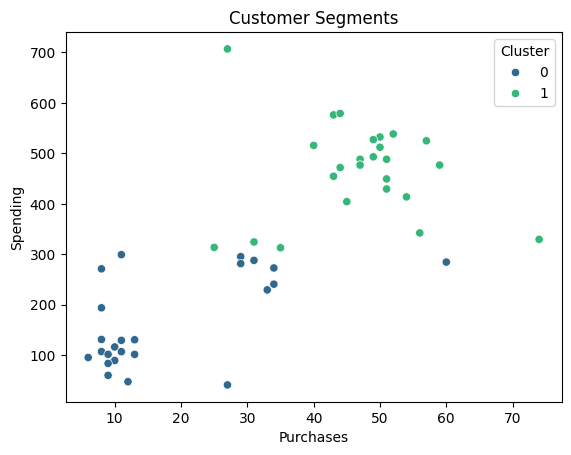

In [ ]:
from sklearn_extra.cluster import KMedoids
kmedoids=KMedoids(n_clusters=2,metric="manhattan",random_state=2026)
data["cluster"]=kmedoids.fit_predict(data)
sns.scatterplot(data=data,x="purchases",y="spending",hue="cluster",palette="viridis")
plt.title("Customer Segments")
plt.xlabel("Purchases")
plt.ylabel("Spending")
plt.legend(title="Cluster")
plt.show()

We see a segmentation of customers where 0 - not very active buyers, and therefore spend little money and bring the company. And 1 - active. However, this distribution does not show the full picture and misses several important points.

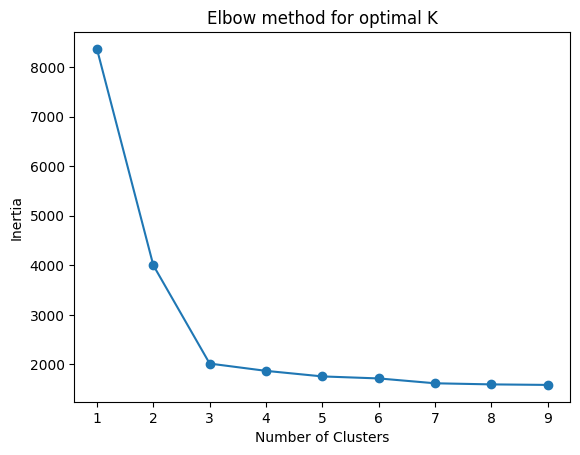

In [ ]:
inertia_values=[]
k_values = range(1,10)
for k in k_values:
  kmedoids = KMedoids(n_clusters=k,metric="manhattan",random_state=2026)
  kmedoids.fit(data)
  inertia_values.append(kmedoids.inertia_)


plt.plot(k_values,inertia_values,marker="o")
plt.title("Elbow method for optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

The optimal value of k=3.

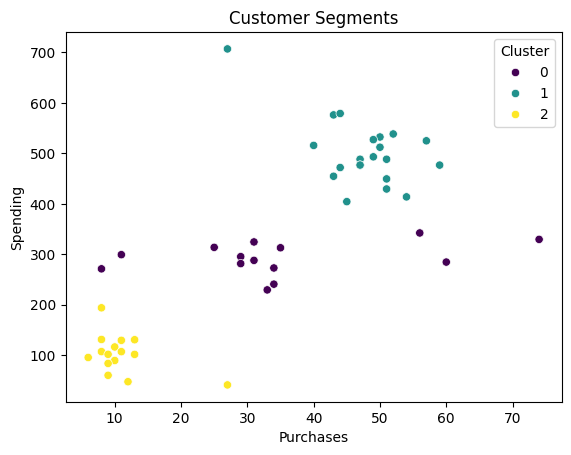

In [ ]:
kmedoids=KMedoids(n_clusters=3,metric="manhattan",random_state=2026)
data["cluster"]=kmedoids.fit_predict(data)
sns.scatterplot(data=data,x="purchases",y="spending",hue="cluster",palette="viridis")
plt.title("Customer Segments")
plt.xlabel("Purchases")
plt.ylabel("Spending")
plt.legend(title="Cluster")
plt.show()

Here we see a more detailed graph, where another value has been added - buyers who made an average number of purchases (approximately 30-40) and also brought an average amount of money to the store, this mark fluctuates between 250-300.

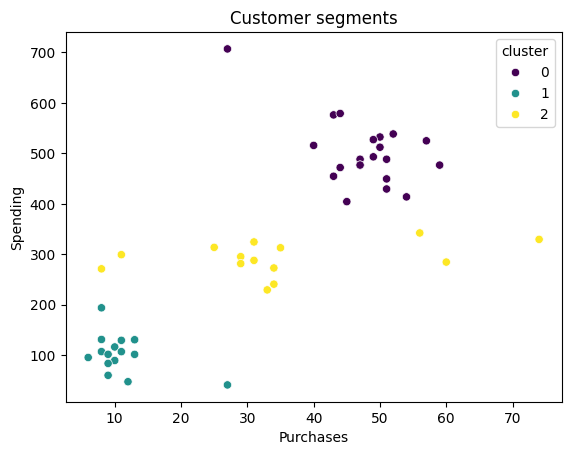

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=2026)
data["cluster"] = kmeans.fit_predict(data)
sns.scatterplot(data=data,x="purchases",y="spending",hue="cluster",palette="viridis")
plt.title("Customer segments")
plt.xlabel("Purchases")
plt.ylabel("Spending")
plt.legend(title="cluster")
plt.show()

KMedoids with K=3 and KMeans with K=3 divided the customers into the same number of clusters, but did so in different ways. In the first plot (KMedoids), the boundaries between the clusters look sharper and more compact, because this algorithm uses real data points as the cluster centers. In the second plot (KMeans), the distribution is more blurred, especially in the middle segment, where there is a noticeable overlap between the clusters.